<a href="https://colab.research.google.com/github/Roshanraj2580/Rice_Leaf_Detection/blob/main/Efficient_Net.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_curve,
    auc,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize


In [ ]:
# Dataset paths
train_dir = "/content/drive/MyDrive/Minor_Project/Data/Splitted/train"
val_dir = "/content/drive/MyDrive/Minor_Project/Data/Splitted/val"
test_dir = "/content/drive/MyDrive/Minor_Project/Data/Splitted/test"

# Model save directory
model_dir = "/content/drive/MyDrive/Minor_Project/Models/EfficientNet"
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, "efficientnet_rice_leaf_model.keras")

# Results save directory
results_dir = os.path.join(model_dir, "results")
os.makedirs(results_dir, exist_ok=True)

# Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 5
LEARNING_RATE = 0.001



In [ ]:

train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)

print("Classes:", class_names)


Found 4150 images belonging to 4 classes.
Found 889 images belonging to 4 classes.
Found 893 images belonging to 4 classes.
Classes: ['Bacterialblight', 'Blast', 'Brownspot', 'Tungro']


In [ ]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

for layer in base_model.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)
output = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_6         │ (None, 224, 224,  │          0 │ input_layer_3[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_3     │ (None, 224, 224,  │          7 │ rescaling_6[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_7         │ (None, 224, 224,  │          0 │ normalization_3[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_7[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,378,535 (16.70 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=model_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    )
]

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks
)

print("Model saved at:", model_path)


Epoch 1/5


KeyboardInterrupt: 

In [ ]:
best_model = load_model(model_path)
print("Loaded model from:", model_path)


Loaded model from: /content/drive/MyDrive/Minor_Project/Models/EfficientNet/efficientnet_rice_leaf_model.keras


In [ ]:
train_loss, train_acc = best_model.evaluate(train_generator, verbose=1)
val_loss, val_acc = best_model.evaluate(val_generator, verbose=1)
test_loss, test_acc = best_model.evaluate(test_generator, verbose=1)

print("\nCore Metrics")
print(f"Train Accuracy      : {train_acc:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")
print(f"Test Accuracy       : {test_acc:.4f}")
print(f"Train Loss          : {train_loss:.4f}")
print(f"Validation Loss     : {val_loss:.4f}")
print(f"Test Loss           : {test_loss:.4f}")


260/260 ━━━━━━━━━━━━━━━━━━━━ 316s 1s/step - accuracy: 0.9995 - loss: 0.0029
56/56 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 1.0000 - loss: 0.0028
56/56 ━━━━━━━━━━━━━━━━━━━━ 615s 11s/step - accuracy: 0.9978 - loss: 0.0070

Core Metrics
Train Accuracy      : 0.9995
Validation Accuracy : 1.0000
Test Accuracy       : 0.9978
Train Loss          : 0.0029
Validation Loss     : 0.0028
Test Loss           : 0.0070


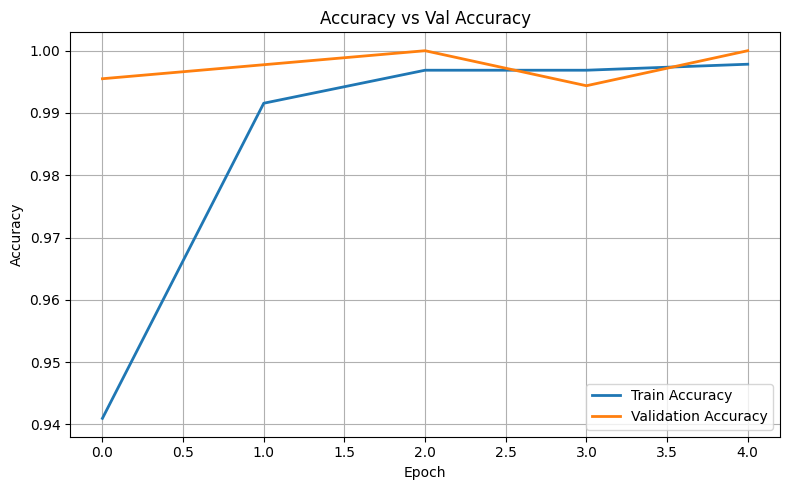

Saved: /content/drive/MyDrive/Minor_Project/Models/EfficientNet/results/accuracy_vs_val_accuracy.png


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy", linewidth=2)
plt.plot(history.history["val_accuracy"], label="Validation Accuracy", linewidth=2)
plt.title("Accuracy vs Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

acc_plot_path = os.path.join(results_dir, "accuracy_vs_val_accuracy.png")
plt.savefig(acc_plot_path, dpi=300)
plt.show()

print("Saved:", acc_plot_path)


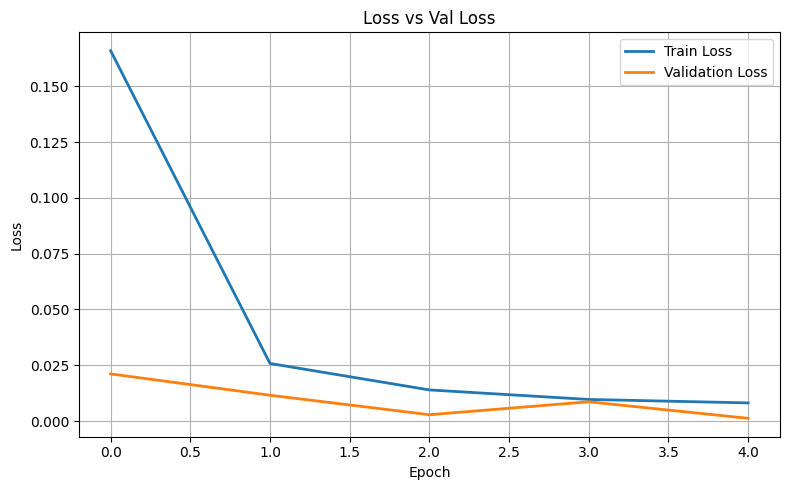

Saved: /content/drive/MyDrive/Minor_Project/Models/EfficientNet/results/loss_vs_val_loss.png


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss", linewidth=2)
plt.plot(history.history["val_loss"], label="Validation Loss", linewidth=2)
plt.title("Loss vs Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

loss_plot_path = os.path.join(results_dir, "loss_vs_val_loss.png")
plt.savefig(loss_plot_path, dpi=300)
plt.show()

print("Saved:", loss_plot_path)


In [ ]:
test_generator.reset()
y_prob = best_model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = test_generator.classes


56/56 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step


In [ ]:
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")
acc = accuracy_score(y_true, y_pred)

print("\nClassification Metrics")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"Accuracy  : {acc:.4f}")


In [ ]:
report = classification_report(y_true, y_pred, target_names=class_names)
print("\nClassification Report\n")
print(report)

report_path = os.path.join(results_dir, "classification_report.txt")
with open(report_path, "w") as f:
    f.write(report)

print("Saved:", report_path)



Classification Report

                 precision    recall  f1-score   support

Bacterialblight       1.00      1.00      1.00       239
          Blast       0.99      1.00      1.00       217
      Brownspot       1.00      0.99      1.00       240
         Tungro       1.00      1.00      1.00       197

       accuracy                           1.00       893
      macro avg       1.00      1.00      1.00       893
   weighted avg       1.00      1.00      1.00       893

Saved: /content/drive/MyDrive/Minor_Project/Models/EfficientNet/results/classification_report.txt


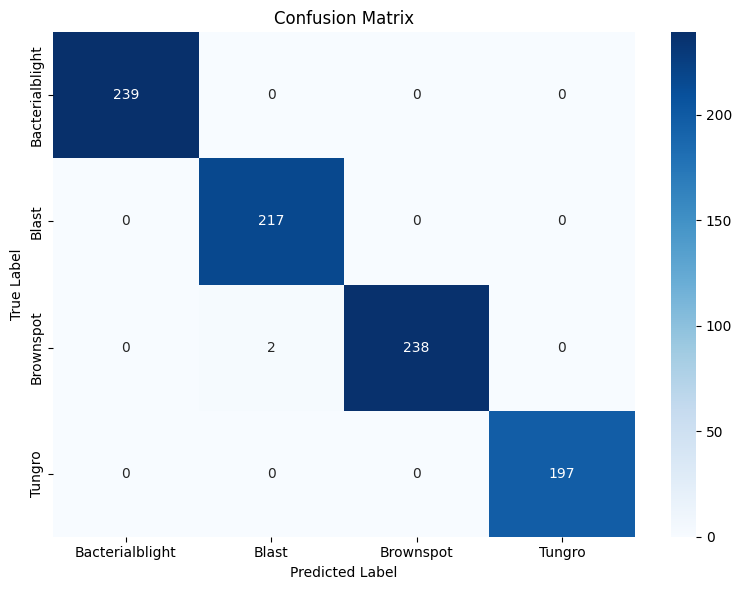

Saved: /content/drive/MyDrive/Minor_Project/Models/EfficientNet/results/confusion_matrix.png


In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

cm_path = os.path.join(results_dir, "confusion_matrix.png")
plt.savefig(cm_path, dpi=300)
plt.show()

print("Saved:", cm_path)


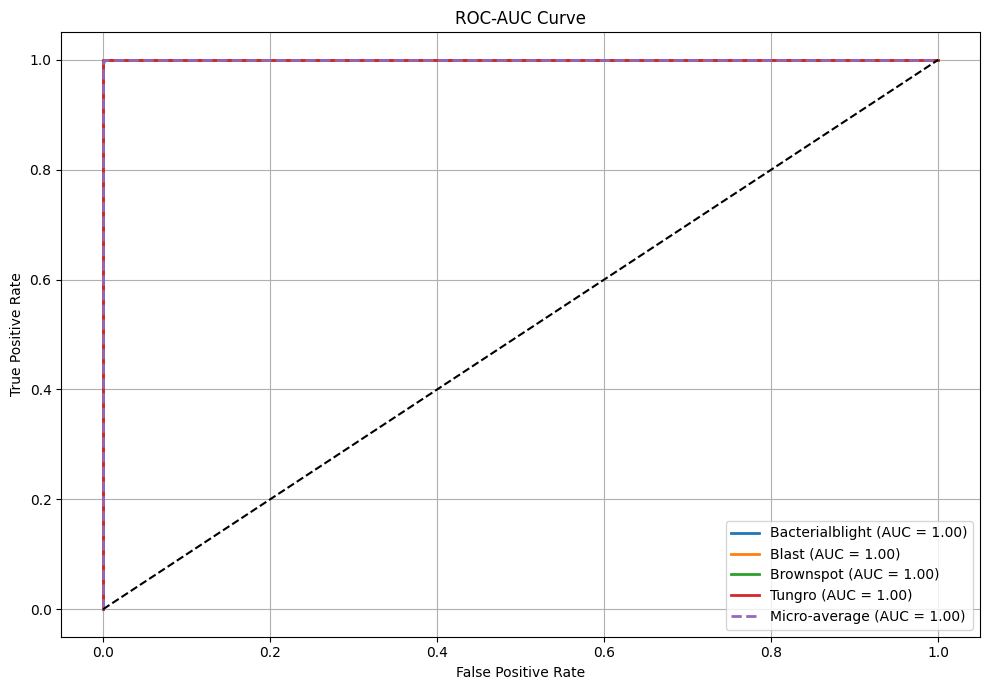

Saved: /content/drive/MyDrive/Minor_Project/Models/EfficientNet/results/roc_auc_curve.png


In [ ]:
y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))

fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(10, 7))

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], linewidth=2, label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")

fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

plt.plot(fpr_micro, tpr_micro, linestyle="--", linewidth=2, label=f"Micro-average (AUC = {roc_auc_micro:.2f})")
plt.plot([0, 1], [0, 1], "k--")
plt.title("ROC-AUC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()

roc_path = os.path.join(results_dir, "roc_auc_curve.png")
plt.savefig(roc_path, dpi=300)
plt.show()

print("Saved:", roc_path)


In [ ]:
roc_auc_macro = roc_auc_score(y_true_bin, y_prob, multi_class="ovr", average="macro")
roc_auc_weighted = roc_auc_score(y_true_bin, y_prob, multi_class="ovr", average="weighted")

print("\nROC-AUC Scores")
print(f"Macro ROC-AUC    : {roc_auc_macro:.4f}")
print(f"Weighted ROC-AUC : {roc_auc_weighted:.4f}")



ROC-AUC Scores
Macro ROC-AUC    : 1.0000
Weighted ROC-AUC : 1.0000


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import os
import json

precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")
acc = accuracy_score(y_true, y_pred)

metrics_dict = {
    "train_accuracy": float(train_acc),
    "validation_accuracy": float(val_acc),
    "test_accuracy": float(test_acc),
    "train_loss": float(train_loss),
    "validation_loss": float(val_loss),
    "test_loss": float(test_loss),
    "precision_weighted": float(precision),
    "recall_weighted": float(recall),
    "f1_score_weighted": float(f1),
    "test_accuracy_sklearn": float(acc),
    "roc_auc_macro": float(roc_auc_macro),
    "roc_auc_weighted": float(roc_auc_weighted)
}

metrics_path = os.path.join(results_dir, "metrics.json")

with open(metrics_path, "w") as f:
    json.dump(metrics_dict, f, indent=4)

print("Saved:", metrics_path)


Saved: /content/drive/MyDrive/Minor_Project/Models/EfficientNet/results/metrics.json


In [ ]:


metrics_dict = {
    "train_accuracy": float(train_acc),
    "validation_accuracy": float(val_acc),
    "test_accuracy": float(test_acc),
    "train_loss": float(train_loss),
    "validation_loss": float(val_loss),
    "test_loss": float(test_loss),
    "precision_weighted": float(precision),
    "recall_weighted": float(recall),
    "f1_score_weighted": float(f1),
    "test_accuracy_sklearn": float(acc),
    "roc_auc_macro": float(roc_auc_macro),
    "roc_auc_weighted": float(roc_auc_weighted)
}

metrics_path = os.path.join(results_dir, "metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics_dict, f, indent=4)

print("Saved:", metrics_path)


Saved: /content/drive/MyDrive/Minor_Project/Models/EfficientNet/results/metrics.json


In [ ]:
summary_path = os.path.join(results_dir, "final_metrics_summary.txt")

with open(summary_path, "w") as f:
    f.write("Final Evaluation Metrics\n")
    f.write("========================\n\n")
    f.write(f"Train Accuracy      : {train_acc:.4f}\n")
    f.write(f"Validation Accuracy : {val_acc:.4f}\n")
    f.write(f"Test Accuracy       : {test_acc:.4f}\n")
    f.write(f"Train Loss          : {train_loss:.4f}\n")
    f.write(f"Validation Loss     : {val_loss:.4f}\n")
    f.write(f"Test Loss           : {test_loss:.4f}\n")
    f.write(f"Precision           : {precision:.4f}\n")
    f.write(f"Recall              : {recall:.4f}\n")
    f.write(f"F1-score            : {f1:.4f}\n")
    f.write(f"Accuracy            : {acc:.4f}\n")
    f.write(f"Macro ROC-AUC       : {roc_auc_macro:.4f}\n")
    f.write(f"Weighted ROC-AUC    : {roc_auc_weighted:.4f}\n")

print("Saved:", summary_path)
print("\nAll results saved in:", results_dir)


Saved: /content/drive/MyDrive/Minor_Project/Models/EfficientNet/results/final_metrics_summary.txt

All results saved in: /content/drive/MyDrive/Minor_Project/Models/EfficientNet/results
